In [1]:
%load_ext autoreload
%autoreload 2

#Import necessary Python modules
import os, warnings, tempfile, pysam, sys
sys.path.append("/public1/biousers/jiachenli/PacBio/NDM.barcode")

import dms_variants.utils
import dms_variants.barcodes
import Bio.SeqIO
import scipy
import itertools
import PacBioCCSsubprocess
import numpy as np
import pandas as pd
import altair as alt

import alignparse.ccs
import alignparse.consensus
import alignparse.minimap2
import alignparse.targets
import alignparse.cs_tag
from alignparse.constants import CBPALETTE
from pathos.helpers import mp

from plotnine import *
from IPython.display import display

In [3]:
current_dir = os.getcwd()
folder = "./output_files/kpc2_align_and_parse"

In [4]:
#Plot the gene and barcode accuracy for each CCS
error_cutoff = 1e-3 # error rates < this set to this
log10_error_floor = -7  # error rates less than this set to this for plotting
log10_error_ceil = -2  # error rates greater than this set to this for plotting
nbins = 100  # bins for cumulative fraction plot

aligned_df = (
    pd.read_csv(folder + "/" + "KPC-2_PacBio_ccs_aligned.csv", na_filter=None)
    .assign(
        gene_error=lambda x: 1 - x["gene_accuracy"],
        barcode_error=lambda x: 1 - x["barcode_accuracy"],
    )
)

display(aligned_df)

cumfrac = (
    aligned_df.melt(
        id_vars=["name", "query_name"],
        value_vars=["barcode_error", "gene_error"],
        value_name="error",
    )
    .assign(log10_error=lambda x: np.log10(x["error"]).clip(lower=log10_error_floor))
    .groupby(["name", "variable"])
    .apply(
        lambda g: pd.DataFrame(
            {
                "cumulative_count": scipy.stats.cumfreq(
                    g["log10_error"],
                    numbins=nbins,
                    defaultreallimits=(log10_error_floor, log10_error_ceil),
                )[0],
                "log10_error": np.linspace(
                    log10_error_floor, log10_error_ceil, nbins
                ),
            }
        )
    )
    .assign(
        meets_accuracy_cutoff=lambda x: x["log10_error"] <= np.log10(error_cutoff),
        cumulative_fraction=lambda x: x["cumulative_count"] / len(aligned_df),
    )
    .reset_index()
)

display(cumfrac)

cumfrac_chart = (
    alt.Chart(cumfrac)
    .encode(
        x=alt.X(
            "log10_error",
            scale=alt.Scale(zero=False),
        ),
        y="cumulative_count",
        color="meets_accuracy_cutoff",
        column=alt.Column("variable", title=None),
        tooltip=[
            alt.Tooltip("log10_error", format=".3f"),
            alt.Tooltip("cumulative_fraction", format=".3f"),
            alt.Tooltip("cumulative_count", format=".4g"),
        ],
    )
    .mark_point(filled=True, size=30)
    .properties(width=260, height=200)
)

display(cumfrac_chart)

,name,query_name,barcode,barcode_sequence,gene_mutations,barcode_accuracy,gene_accuracy,gene_error,barcode_error
0,kpc_pacbio,m64284e_240816_165925/9/ccs,GGGATTAATTCTTTGGTTAA,TTAACCAAAGAATTAATCCC,,1.000000,1.000000,3.197581e-09,3.159548e-07
1,kpc_pacbio,m64284e_240816_165925/11/ccs,GGGACGACATTGGCGTCCTT,AAGGACGCCAATGTCGTCCC,del546to546 G548A del574to574 C587G T588G ins607C,0.999852,0.997832,2.167554e-03,1.483630e-04
2,kpc_pacbio,m64284e_240816_165925/13/ccs,CGTCTCGGTCGGTCACTTCG,CGAAGTGACCGACCGAGACG,,0.974211,0.999979,2.059916e-05,2.578878e-02
3,kpc_pacbio,m64284e_240816_165925/20/ccs,GGGTAAGCTGTCGTCATCTG,CAGATGACGACAGCTTACCC,del547to547 A687C,0.999998,0.999989,1.135124e-05,1.583818e-06
4,kpc_pacbio,m64284e_240816_165925/22/ccs,ATCGCGTACAATTGTATGTT,AACATACAATTGTACGCGAT,A287G C288G,1.000000,1.000000,5.011872e-10,5.011872e-10
...,...,...,...,...,...,...,...,...,...
2581452,kpc_pacbio,m64284e_240816_165925/180554574/ccs,CAGCAGTTCCGGGTGGGGAA,TTCCCCACCCGGAACTGCTG,ins470C ins548A T625A G683A,0.960164,0.998864,1.136203e-03,3.983603e-02
2581453,kpc_pacbio,m64284e_240816_165925/180554576/ccs,ATTAACTACTTTCTAAGATT,AATCTTAGAAAGTAGTTAAT,C522T,1.000000,0.999943,5.682445e-05,5.011872e-10
2581454,kpc_pacbio,m64284e_240816_165925/180554583/ccs,TGGTCTATTGGCTCGGTTTG,CAAACCGAGCCAATAGACCA,ins36TC ins103A ins314CA ins396CG ins582A ins6...,1.000000,0.998906,1.093813e-03,5.011872e-10
2581455,kpc_pacbio,m64284e_240816_165925/180554584/ccs,TAGTAAATGTCATGGTAACT,AGTTACCATGACATTTACTA,T10C T12A T26G,1.000000,0.999943,5.682445e-05,5.011872e-10


/tmp/ipykernel_53602/3545800743.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,name,variable,level_2,cumulative_count,log10_error,meets_accuracy_cutoff,cumulative_fraction
0,kpc_pacbio,barcode_error,0,1289589.0,-7.000000,True,0.499559
1,kpc_pacbio,barcode_error,1,1291350.0,-6.949495,True,0.500241
2,kpc_pacbio,barcode_error,2,1297903.0,-6.898990,True,0.502779
3,kpc_pacbio,barcode_error,3,1299773.0,-6.848485,True,0.503504
4,kpc_pacbio,barcode_error,4,1306354.0,-6.797980,True,0.506053
...,...,...,...,...,...,...,...
195,kpc_pacbio,gene_error,95,2521536.0,-2.202020,False,0.976788
196,kpc_pacbio,gene_error,96,2537905.0,-2.151515,False,0.983129
197,kpc_pacbio,gene_error,97,2552980.0,-2.101010,False,0.988969
198,kpc_pacbio,gene_error,98,2565701.0,-2.050505,False,0.993896


alt.Chart(...)

In [5]:
#Remove CCSs that do not meet accuracy threshold
print("There are %d CCSs before accuracy filtering." % (len(aligned_df)))

inclusion_df = (
    aligned_df
    .query("barcode_error <= @error_cutoff")
    .query("gene_error <= @error_cutoff")
)

print("After filtering %d CCSs remain." % (len(inclusion_df)))
inclusion_df

There are 2581457 CCSs before accuracy filtering.
After filtering 1611953 CCSs remain.


,name,query_name,barcode,barcode_sequence,gene_mutations,barcode_accuracy,gene_accuracy,gene_error,barcode_error
0,kpc_pacbio,m64284e_240816_165925/9/ccs,GGGATTAATTCTTTGGTTAA,TTAACCAAAGAATTAATCCC,,1.000000,1.000000,3.197581e-09,3.159548e-07
3,kpc_pacbio,m64284e_240816_165925/20/ccs,GGGTAAGCTGTCGTCATCTG,CAGATGACGACAGCTTACCC,del547to547 A687C,0.999998,0.999989,1.135124e-05,1.583818e-06
4,kpc_pacbio,m64284e_240816_165925/22/ccs,ATCGCGTACAATTGTATGTT,AACATACAATTGTACGCGAT,A287G C288G,1.000000,1.000000,5.011872e-10,5.011872e-10
6,kpc_pacbio,m64284e_240816_165925/26/ccs,TCTCGATCGGGGACACTGAA,TTCAGTGTCCCCGATCGAGA,del73to73 A79C A130T T131A del177to177,0.999987,1.000000,4.619359e-08,1.261236e-05
7,kpc_pacbio,m64284e_240816_165925/28/ccs,GTCATCGGCCATTTTGGCTG,CAGCCAAAATGGCCGATGAC,ins331G ins547C ins572C A572T A573G,1.000000,0.999614,3.857029e-04,5.011872e-10
...,...,...,...,...,...,...,...,...,...
2581448,kpc_pacbio,m64284e_240816_165925/180554566/ccs,TAGGACTCCCTTACAAGATT,AATCTTGTAAGGGAGTCCTA,A754C C755G T756A C831A,1.000000,1.000000,5.011872e-10,5.011872e-10
2581449,kpc_pacbio,m64284e_240816_165925/180554567/ccs,TTGTTCTACACCTGACTTTA,TAAAGTCAGGTGTAGAACAA,G262A C264A C794T G795T,1.000000,0.999808,1.916952e-04,2.077244e-08
2581450,kpc_pacbio,m64284e_240816_165925/180554570/ccs,ATCTGCTCGTGATCTCATCT,AGATGAGATCACGAGCAGAT,G184C A185G G186A,1.000000,1.000000,5.011872e-10,5.011872e-10
2581453,kpc_pacbio,m64284e_240816_165925/180554576/ccs,ATTAACTACTTTCTAAGATT,AATCTTAGAAAGTAGTTAAT,C522T,1.000000,0.999943,5.682445e-05,5.011872e-10


In [6]:
#ref_file = Bio.SeqIO.read("./KPC-2_amplicon.gb", "genbank")
#ref_seq = str(ref_file.seq)[40:922]
#display(ref_seq)

#inclusion_df = (
#    inclusion_df.assign(
#        mutations_inframe=lambda x: x["gene_mutations"].map(deltosubs.dels_to_subs),
#        deletion=lambda x: x["gene_mutations"] != x["mutations_inframe"],
#    )
#    .drop(columns="gene_mutations")
#    .rename(columns={"mutations_inframe": "gene_mutations"})
#)

#print("Number of CCSs with in-frame deletions:")
#display(
#    inclusion_df.groupby("deletion")
#    .aggregate(n_CCSs=pd.NamedAgg("query_name", "count"))
#    .assign(fraction=lambda x: x["n_CCSs"] / x["n_CCSs"].sum())
#    .round(3)
#)

,barcode,count
0,AAAAAAAAAGTCGACCGGAT,2
1,AAAAAAAACAAGAAAGTCAG,1
2,AAAAAAAACACATTTATGAT,3
3,AAAAAAAACTTACAGGCGCG,1
4,AAAAAAAATACATTTCGGAT,1
...,...,...
731276,TTTTTTTTTTTTTGGATCGG,2
731277,TTTTTTTTTTTTTTCCAGGA,2
731278,TTTTTTTTTTTTTTTCCTTA,1
731279,TTTTTTTTTTTTTTTTCTTT,2


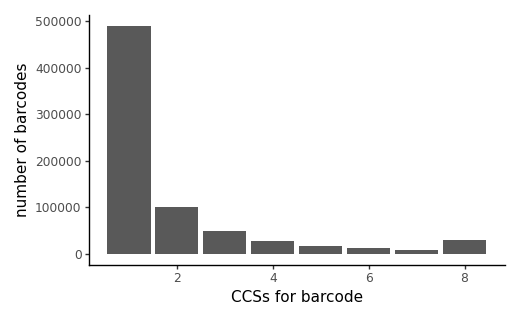

alt.Chart(...)

In [7]:
# group barcodes with >= this many CCSs
max_CCSs = 8

# number of counts for each barcode
barcodecounts = (
    inclusion_df
    .groupby("barcode", as_index=False)
    .aggregate(count=pd.NamedAgg("query_name", "count"))
)

display(barcodecounts)

p = (
    ggplot(
        barcodecounts
        .assign(nseqs=lambda x: np.clip(x["count"], None, max_CCSs)),
        aes("nseqs"),
    )
    + geom_bar()
    + theme_classic() 
    + theme(
        figure_size=(5, 3),
        panel_grid_major_x=element_blank(),  # no vertial tick lines
    )
    + ylab("number of barcodes")
    + xlab("CCSs for barcode")
)

display(p.draw())

# make rarefaction plot
rarefy_df = pd.concat(
    [
        (
            dms_variants.barcodes.rarefyBarcodes(
                barcodecounts, maxpoints=1000, logspace=False
            )
        )
    ]
)

rarefy_chart = (
    alt.Chart(rarefy_df)
    .encode(
        x=alt.X(
            "ncounts",
            title="number of CCSs",
        ),
        y=alt.X(
            "nbarcodes",
            title="number of barcodes",
        ),
        tooltip=rarefy_df.columns.tolist(),
    )
    .mark_point(size=10, filled=True)
    .resolve_scale(y="independent")
    .properties(height=300, width=400)
)

display(rarefy_chart)

In [8]:
# required CCSs per barcode to call consensus below
min_support = 3

# compute diversity statistics
diversity = (
    dms_variants.barcodes.inverse_simpson_index(barcodecounts.assign(library="ndm_pacbio"))
    .melt(
        id_vars="library",
        value_vars="inverse_simpson_index",
        var_name="metric",
        value_name="diversity",
    )
)

display(diversity)

for n in range(min_support):
    diversity = pd.concat(
        [
            diversity,
            barcodecounts.assign(library="ndm_pacbio")
            .query("count > @n")
            .groupby("library", as_index=False)
            .aggregate(diversity=pd.NamedAgg("barcode", "nunique"))
            .assign(metric=f"barcodes with >{n} CCSs"),
        ],
        ignore_index=True,
    )
diversity_chart = (
    alt.Chart(diversity)
    .encode(
        x=alt.X("diversity"),
        y=alt.Y("metric", title=None),
        tooltip=diversity.columns.tolist(),
    )
    .mark_bar()
    .properties(width=400, height=30 * (min_support + 1))
)
display(diversity_chart)

,library,metric,diversity
0,ndm_pacbio,inverse_simpson_index,109899.956415


alt.Chart(...)

In [9]:
inclusion_df = (
    alignparse.consensus.add_mut_info_cols(
        inclusion_df, 
        mutation_col="gene_mutations", 
        n_indel_col="n_indels",
        overwrite_cols=True,
    )
    .assign(
        has_indel=lambda x: x["n_indels"] > 0
    )
)

inclusion_df

,name,query_name,barcode,barcode_sequence,gene_mutations,barcode_accuracy,gene_accuracy,gene_error,barcode_error,n_indels,has_indel
0,kpc_pacbio,m64284e_240816_165925/9/ccs,GGGATTAATTCTTTGGTTAA,TTAACCAAAGAATTAATCCC,,1.000000,1.000000,3.197581e-09,3.159548e-07,0,False
1,kpc_pacbio,m64284e_240816_165925/20/ccs,GGGTAAGCTGTCGTCATCTG,CAGATGACGACAGCTTACCC,del547to547 A687C,0.999998,0.999989,1.135124e-05,1.583818e-06,1,True
2,kpc_pacbio,m64284e_240816_165925/22/ccs,ATCGCGTACAATTGTATGTT,AACATACAATTGTACGCGAT,A287G C288G,1.000000,1.000000,5.011872e-10,5.011872e-10,0,False
3,kpc_pacbio,m64284e_240816_165925/26/ccs,TCTCGATCGGGGACACTGAA,TTCAGTGTCCCCGATCGAGA,del73to73 A79C A130T T131A del177to177,0.999987,1.000000,4.619359e-08,1.261236e-05,2,True
4,kpc_pacbio,m64284e_240816_165925/28/ccs,GTCATCGGCCATTTTGGCTG,CAGCCAAAATGGCCGATGAC,ins331G ins547C ins572C A572T A573G,1.000000,0.999614,3.857029e-04,5.011872e-10,3,True
...,...,...,...,...,...,...,...,...,...,...,...
1611948,kpc_pacbio,m64284e_240816_165925/180554566/ccs,TAGGACTCCCTTACAAGATT,AATCTTGTAAGGGAGTCCTA,A754C C755G T756A C831A,1.000000,1.000000,5.011872e-10,5.011872e-10,0,False
1611949,kpc_pacbio,m64284e_240816_165925/180554567/ccs,TTGTTCTACACCTGACTTTA,TAAAGTCAGGTGTAGAACAA,G262A C264A C794T G795T,1.000000,0.999808,1.916952e-04,2.077244e-08,0,False
1611950,kpc_pacbio,m64284e_240816_165925/180554570/ccs,ATCTGCTCGTGATCTCATCT,AGATGAGATCACGAGCAGAT,G184C A185G G186A,1.000000,1.000000,5.011872e-10,5.011872e-10,0,False
1611951,kpc_pacbio,m64284e_240816_165925/180554576/ccs,ATTAACTACTTTCTAAGATT,AATCTTAGAAAGTAGTTAAT,C522T,1.000000,0.999943,5.682445e-05,5.011872e-10,0,False


In [10]:
(
    inclusion_df
    .groupby(["name", "has_indel"])
    .size()
    .rename("number_CCSs")
    .reset_index()
)

,name,has_indel,number_CCSs
0,kpc_pacbio,False,911143
1,kpc_pacbio,True,700810


In [11]:
# compute empirical accuracies
empirical_acc = []
for no_indel, acc_10x in itertools.product([True, False], [True, False]):
    df = inclusion_df.copy()
    if not no_indel:
        df = df.query("n_indels == 0")
        label = "no indels"
    else:
        label = "allow indels"
    if acc_10x:
        max_error_rate_10x = error_cutoff / 10
        df = df.query("barcode_error <= @max_error_rate_10x").query(
            "gene_error <= @max_error_rate_10x"
        )
        label += ", 10x accuracy"
    empirical_acc.append(
        alignparse.consensus.empirical_accuracy(
            df, upstream_group_cols=None, mutation_col="gene_mutations"
        ).assign(label=label)
    )
empirical_acc = pd.concat(empirical_acc, ignore_index=True)

display(empirical_acc)

# plot empirical accuracy
print("Empirical accuracies:")
empirical_acc_chart = (
    alt.Chart(empirical_acc)
    .encode(
        x=alt.X(
            "accuracy:Q",
            scale=alt.Scale(domain=(0, 1)),
        ),
        y=alt.Y(
            "label:N",
            axis=alt.Axis(title=None),
        ),
        tooltip=[alt.Tooltip("accuracy", format=".3f")],
    )
    .mark_point(filled=True, size=150)
    .properties(width=400, height=200)
)
display(empirical_acc_chart)

,accuracy,label
0,0.512904,"allow indels, 10x accuracy"
1,0.437142,allow indels
2,0.641918,"no indels, 10x accuracy"
3,0.625918,no indels


Empirical accuracies:


alt.Chart(...)

In [12]:
# get parameters for building consensus
consensus_params = {
    "max_sub_diffs": None,
    "max_indel_diffs": None,
    "max_minor_sub_frac": 0.2,
    "max_minor_indel_frac": 0.2,
    "min_support": 1
    }
print(
    "Building consensus sequences with following settings\n  "
    + "\n  ".join(f"{param}={val}" for param, val in consensus_params.items())
)

# build consensus sequences and plot results
max_plot_nseqs = 15  # group nseqs >= this together
plot_width = 400

consensus, dropped = alignparse.consensus.simple_mutconsensus(
    inclusion_df, 
    mutation_col="gene_mutations",
    group_cols="barcode",
    **consensus_params,
)

consensus_stats = (
    pd.concat(
        [
            consensus.rename(columns={"variant_call_support": "nseqs"})
            .drop(columns="gene_mutations")
            .assign(drop_reason="retained", dropped=False),
            dropped.assign(dropped=True),
        ]
    )
    .assign(nseqs=lambda x: x["nseqs"].clip(upper=max_plot_nseqs))
    .groupby(["drop_reason", "dropped", "nseqs"], as_index=False)
    .aggregate(
        n_barcodes=pd.NamedAgg("barcode", "count"),
        n_CCSs=pd.NamedAgg("nseqs", "sum"),
    )
    .rename(columns={"drop_reason": "category"})
    .melt(
        id_vars=["category", "dropped", "nseqs"],
        value_vars=["n_barcodes", "n_CCSs"],
        var_name="type_of_count",
        value_name="count",
    )
)

# get drop reasons in order to plot
drop_reasons = (
    consensus_stats.groupby(["category", "dropped"], as_index=False)
    .aggregate({"count": "sum"})
    .sort_values(["dropped", "count"], ascending=[True, False])["category"]
    .tolist()
)
drop_colors = ["blue", "orange", "orangered", "goldenrod", "gold", "darkorange"]
assert len(drop_reasons) <= len(drop_colors)

consensus_stats_chart = (
    alt.Chart(consensus_stats)
    .encode(
        x=alt.X(
            "nseqs",
            scale=alt.Scale(domain=(1, max_plot_nseqs)),
            title="number of CCSs for barcode",
        ),
        y=alt.Y("count", stack=True),
        color=alt.Color(
            "category",
            sort=drop_reasons,
            scale=alt.Scale(range=drop_colors),
        ),
        column=alt.Column("type_of_count"),
        tooltip=consensus_stats.columns.tolist(),
    )
    .mark_bar(size=0.75 * plot_width / max_plot_nseqs)
    .properties(width=plot_width, height=200)
    .configure_axis(grid=False)
    .resolve_scale(y="independent")
)

display(consensus_stats_chart)

Building consensus sequences with following settings
  max_sub_diffs=None
  max_indel_diffs=None
  max_minor_sub_frac=0.2
  max_minor_indel_frac=0.2
  min_support=1


alt.Chart(...)

In [13]:
display(dropped)

(dropped.groupby("drop_reason").size().rename("number_barcodes").reset_index())

,barcode,drop_reason,nseqs
0,AAAAAAACGGTGTGGCTATC,minor subs too frequent,5
1,AAAAAAATGTTTAAACTCAC,minor subs too frequent,7
2,AAAAAAGGCCTGATCCGCGA,minor subs too frequent,4
3,AAAAAAGTGTGCACACTTGA,minor subs too frequent,11
4,AAAAACAATGTGTACGTTTA,minor subs too frequent,9
...,...,...,...
52429,TTTTTTTTTAGTTACCTACT,minor subs too frequent,18
52430,TTTTTTTTTGAGGAGCACGT,minor subs too frequent,24
52431,TTTTTTTTTTCTGCTATTTA,minor subs too frequent,17
52432,TTTTTTTTTTTGGCTGTCGA,minor subs too frequent,9


,drop_reason,number_barcodes
0,minor indels too frequent,2970
1,minor subs too frequent,49464


In [14]:
# annotate with information on mutation types
consensus = alignparse.consensus.add_mut_info_cols(
    consensus,
    mutation_col="gene_mutations",
    sub_str_col="substitutions",
    n_indel_col="n_indels",
).rename(columns={"gene_mutations": "gene_mutation"})

# plot summary stats
stats = (
    consensus.assign(
        out_of_frame_indel=lambda x: x["n_indels"] > 0,
        in_frame_codon_deletion=lambda x: (
            (~x["out_of_frame_indel"]) & (x["substitutions"].str.contains("-"))
        ),
        no_indel=lambda x: (~x["out_of_frame_indel"]) & (~x["in_frame_codon_deletion"]),
        name="ndm_pacbio",
    )[["name", "out_of_frame_indel", "in_frame_codon_deletion", "no_indel"]]
    .groupby("name", as_index=False)
    .aggregate("sum")
    .melt(
        id_vars="name",
        var_name="category",
        value_name="n_barcodes",
    )
    .assign(retained=lambda x: x["category"] != "out_of_frame_indel")
)
 
stats_chart = (
    alt.Chart(stats)
    .encode(
        x=alt.X("n_barcodes"),
        y=alt.Y("category", title=None),
        color=alt.Color("retained"),
        tooltip=stats.columns.tolist(),
    )
    .mark_bar()
    .properties(width=300, height=100)
)
display(stats_chart)

alt.Chart(...)

In [15]:
consensus

,barcode,gene_mutation,variant_call_support,substitutions,n_indels
0,AAAAAAAAAGTCGACCGGAT,G820A A821C,2,G820A A821C,0
1,AAAAAAAACAAGAAAGTCAG,C814A A815C C816T,1,C814A A815C C816T,0
2,AAAAAAAACACATTTATGAT,C182A C273G G376A,3,C182A C273G G376A,0
3,AAAAAAAACTTACAGGCGCG,T43A G44A,1,T43A G44A,0
4,AAAAAAAATACATTTCGGAT,A1C,1,A1C,0
...,...,...,...,...,...
678842,TTTTTTTTTTTTTGGATCGG,,2,,0
678843,TTTTTTTTTTTTTTCCAGGA,C601G G603A,2,C601G G603A,0
678844,TTTTTTTTTTTTTTTCCTTA,C68T C69A ins526GCGCGCGATACCTCGCG,1,C68T C69A,1
678845,TTTTTTTTTTTTTTTTCTTT,,2,,0


In [16]:
consensus.query("n_indels==0").drop("n_indels", axis=1).to_csv(os.path.join(current_dir, folder) + "/" + "KPC-2_PacBio_consensus.csv", index=False)

In [17]:
# = (
#    consensus
#    .query("n_indels==0")
#    .reset_index()
#    .assign(protein_mutation=lambda x: PacBioCCSsubprocess.ntlist_transform(ref_seq, x["gene_mutation"]))
#    .assign(mutation_type=lambda x: PacBioCCSsubprocess.classify_mutations_batch(x["gene_mutation"], x["protein_mutation"]))
#)
#consensus_aa

In [18]:
#aa_list = [i for i in consensus_aa["protein_mutation"] if len(i.split(" ")) == 1]
#stop_list = [i for i in aa_list if i.endswith("*")]
#display(len(np.unique(aa_list)), stop_list)